# Sistema de monitoreo de telares y vibración

**Elaborado por: Juan de Jesús Gómez López**

> **Universidad Autónoma Metropolitana**  

---

## ¿Qué hace este sistema?

Este proyecto implementa un sistema de **control de calidad y mantenimiento predictivo** para telares industriales, combinando dos fuentes de información:

| Fuente | ¿Qué detecta? | Herramienta |
|---|---|---|
| Señal de vibración | Fallos mecánicos: frecuencia anómala, golpes, desgaste | NumPy + FFT |
| Imagen de la tela | Defectos visuales: huecos, cortes, contaminación | OpenCV |
| Correlación | Fallos confirmados por ambas fuentes simultáneamente | Pandas |

**Premisa central:** una máquina que falla mecánicamente también produce tela defectuosa.  
Cuando ambas fuentes coinciden se tiene una **alerta de alta confianza**.

---

## Método de ejecución

```
1. Simulación de vibraciones (NumPy)
2. Análisis FFT y detección de anomalías (NumPy + Pandas)
3. Visión artificial sobre dataset MVTec AD (OpenCV)
4. Correlación multimodal y dashboard de alertas (Matplotlib)
```

---

In [5]:
from pathlib import Path

# ── AJUSTA ESTA RUTA ──────────────────────────────────────────
MVTEC_ROOT = Path("Datos_Imagenes_Tela")
# ─────────────────────────────────────────────────────────────

BASE_DIR     = Path("data")
VIB_DIR      = BASE_DIR / "vibration"
ANALYSIS_DIR = BASE_DIR / "analysis"
VISION_DIR   = BASE_DIR / "vision_output"
DASH_DIR     = BASE_DIR / "dashboard"

# Crear carpetas si no existen
for d in [VIB_DIR, ANALYSIS_DIR, VISION_DIR, DASH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Configuración lista')
print(f'  Dataset MVTec : {MVTEC_ROOT}')
print(f'  Salida base   : {BASE_DIR.resolve()}')

Configuración lista
  Dataset MVTec : Datos_Imagenes_Tela
  Salida base   : C:\Users\pakoy\Documents\Cursos\Cursos_Intertrimestrales_UAM\Phyton\Proyecto\data


---
## Simulación de Vibraciones

Generamos señales sintéticas que simulan el comportamiento de un telar industrial.

**Modelo matemático:**
```
señal(t) = A₁·sin(2π·25Hz·t)   ← frecuencia fundamental
         + A₂·sin(2π·50Hz·t)   ← armónico
         + ruido gaussiano
         + [anomalía opcional]  ← fallo inyectado
```

**Tres tipos de fallo simulados:**
- `frequency` — aparece una nueva frecuencia (rodamiento desgastado)
- `spike` — golpes periódicos (hilo roto)
- `drift` — amplitud creciente (desgaste progresivo)


═══════════════════════════════════════════════════════
  TELAR MONITOR — Simulación de Vibraciones
═══════════════════════════════════════════════════════

 1: Generando señal normal base...
Guardado: data\vibration\normal.csv  (10,000 filas)

3: Procesando anomalía: FREQUENCY...
Guardado: data\vibration\faulty_frequency.csv  (10,000 filas)


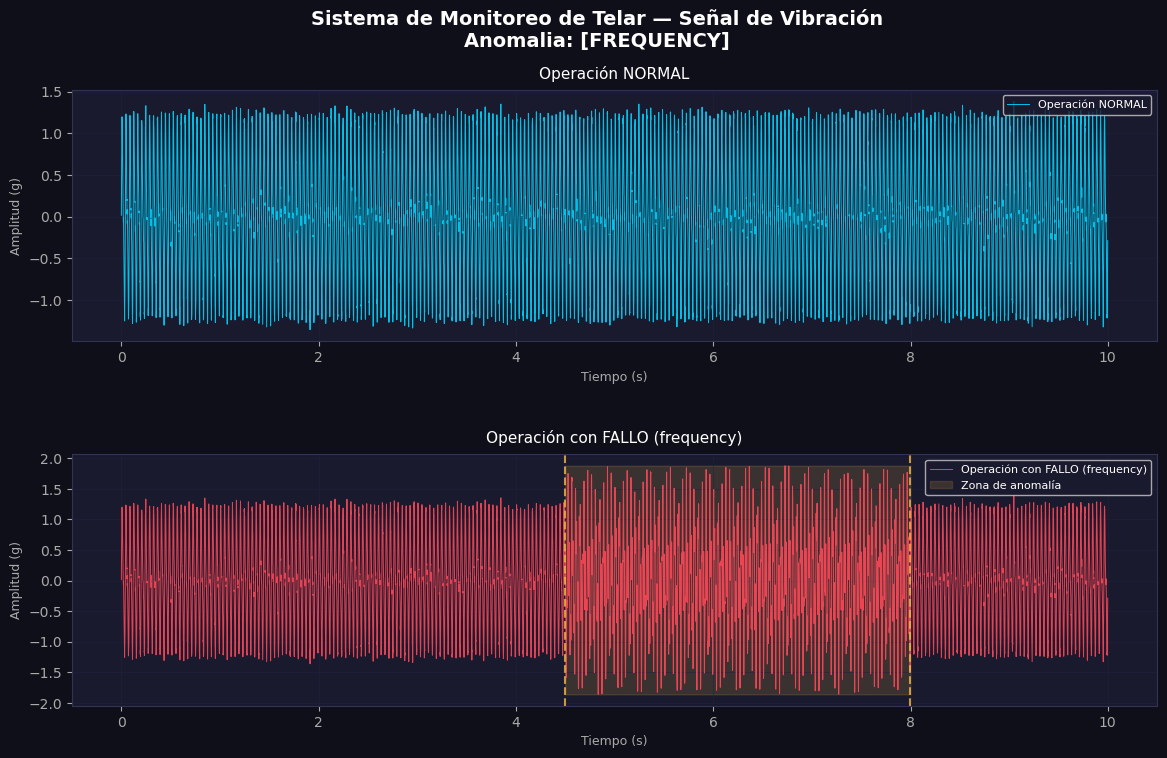


4: Procesando anomalía: SPIKE...
Guardado: data\vibration\faulty_spike.csv  (10,000 filas)


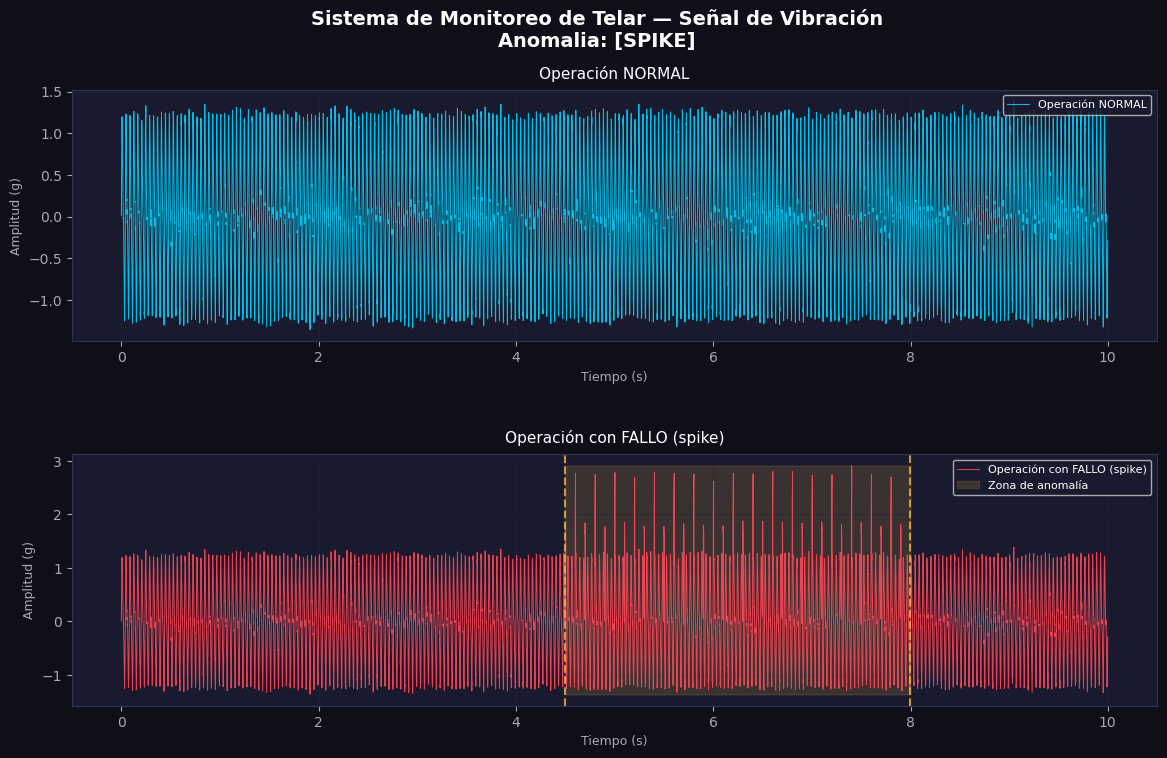


5: Procesando anomalía: DRIFT...
Guardado: data\vibration\faulty_drift.csv  (10,000 filas)


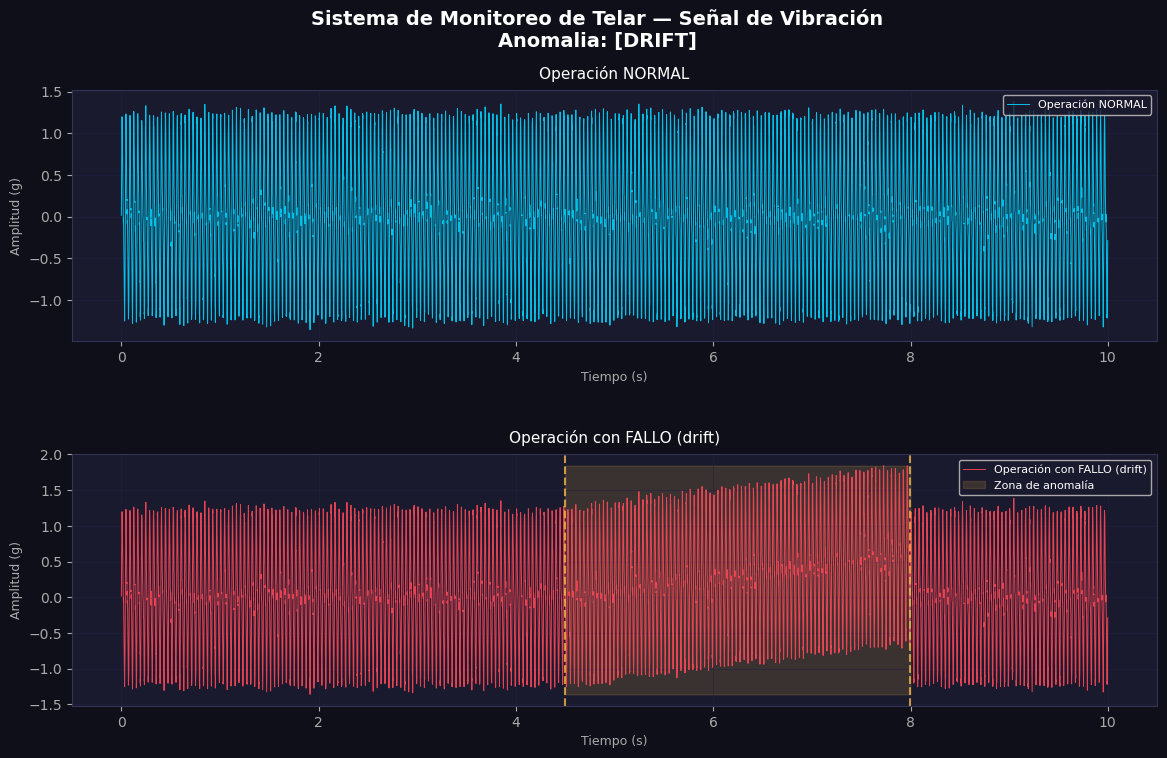


───────────────────────────────────────────────────────
  RESUMEN ESTADÍSTICO
───────────────────────────────────────────────────────
     experimento  muestras  amp_media  amp_std  amp_max  pct_anomalia
          normal     10000    -0.0005   0.7639   1.3864           0.0
faulty_frequency     10000    -0.0005   0.8040   1.8766          35.0
    faulty_spike     10000     0.0310   0.8075   2.9084          35.0
    faulty_drift     10000     0.1045   0.7833   1.8425          35.0

 Resumen guardado: data\vibration\summary.csv
═══════════════════════════════════════════════════════


Señales generadas: ['normal', 'faulty_frequency', 'faulty_spike', 'faulty_drift']


In [6]:
import sys
sys.path.insert(0, '.')  # Asegurar que src/ es accesible

from Vibracion_Sim import run_simulation

vib_results = run_simulation(output_base=VIB_DIR)
print(f"\nSeñales generadas: {list(vib_results.keys())}")

---
## Análisis FFT y Detección de Anomalías

Transformamos las señales del **dominio del tiempo** al **dominio de la frecuencia** usando FFT.

Esto nos permite detectar:
- **Picos en frecuencias prohibidas** relacionado con un fallo de frecuencia
- **Amplitudes sobre umbral** relacionado con un fallo tipo spike  
- **Energía creciente en ventana rodante** relacionado con un fallo tipo drift

Se aplica una **ventana de Hanning** para evitar *spectral leakage*.

In [7]:
from FFT_analysys import run_analysis

fft_report = run_analysis(
    data_dir=VIB_DIR,
    output_dir=ANALYSIS_DIR
)


══════════════════════════════════════════════════════════
  TELAR MONITOR — Análisis FFT y Detección de Anomalías
══════════════════════════════════════════════════════════

 Señal normal:
Cargado: normal.csv  (10,000 muestras)
 Alertas  por frecuencia detectadas: 0 / 38 ventanas

──────────────────────────────────────────────────────────
  Procesando: FREQUENCY
──────────────────────────────────────────────────────────
Cargado: faulty_frequency.csv  (10,000 muestras)
 Alertas  por frecuencia detectadas: 14 / 38 ventanas
 Alertas  por spike detectadas: 0 / 10000 ventanas
 Alertas  por drift detectadas: 3505 / 10000 ventanas
Reporte guardado: data\analysis\report_frequency.csv
Figura: data\analysis\fft_analysis_frequency.png

──────────────────────────────────────────────────────────
  Procesando: SPIKE
──────────────────────────────────────────────────────────
Cargado: faulty_spike.csv  (10,000 muestras)
 Alertas  por frecuencia detectadas: 0 / 38 ventanas
 Alertas  por spike detecta

---
## Visión Artificial con OpenCV

Analizamos imágenes del dataset **MVTec AD** (categorías `carpet` y `grid`).

**Método por imagen:**
1. Preprocesamiento (resize, escala de grises, blur gaussiano)
2. Detección de bordes con Canny y Sobel
3. Análisis de contornos sospechosos
4. Análisis por parches locales (inspirado en PatchCore)
5. Score de defecto 0.0 → 1.0

**Umbral adaptativo:** telas densas como carpet usan un umbral más bajo  
calculado automáticamente a partir del baseline de imágenes normales.

In [ ]:
from Vision_analysis import analyze_mvtec_category

vision_results = {}

for category in ["carpet", "grid"]:
    cat_path = MVTEC_ROOT / category
    if not cat_path.exists():
        print(f" No encontrado: {cat_path} ")
        continue
    vision_results[category] = analyze_mvtec_category(
        category_path=cat_path,
        output_dir=VISION_DIR
    )


══════════════════════════════════════════════════════════
  Analizando categoría: CARPET
══════════════════════════════════════════════════════════
  Construyendo baseline con imágenes de: Datos_Imagenes_Tela\carpet\train\good
 Baseline calculado con 30 imágenes
  edge_density media : 0.39772
  sobel_mean media   : 92.630
  Baseline calculado con 30 imágenes
    edge_density media : 0.39772
    sobel_mean media   : 92.630
 Tela densa detectada => umbral adaptativo: 0.18

  Clase: color                     (15 imágenes)

  Clase: cut                       (15 imágenes)

  Clase: good                      (15 imágenes)

  Clase: hole                      (15 imágenes)

  Clase: metal_contamination       (15 imágenes)

  Clase: thread                    (15 imágenes)

  ────────────────────────────────────────
  MÉTRICAS — CARPET
  ────────────────────────────────────────
  Accuracy  : 41.1%
  Precision : 78.9%
  Recall    : 40.0%
  F1 Score  : 53.1%
  TP=30 TN=7 FP=8 FN=45

  Resultado

### Resumen de métricas de visión

In [9]:
import pandas as pd

for cat, df in vision_results.items():
    print(f"\n── {cat.upper()} ──")
    summary = df.groupby("defect_class")["defect_score"].agg(["mean","min","max","count"])
    print(summary.round(3).to_string())


── CARPET ──
                      mean    min    max  count
defect_class                                   
color                0.150  0.000  0.320     15
cut                  0.155  0.000  0.408     15
good                 0.267  0.000  0.714     15
hole                 0.142  0.012  0.408     15
metal_contamination  0.145  0.000  0.306     15
thread               0.173  0.009  0.408     15

── GRID ──
                      mean    min    max  count
defect_class                                   
bent                 1.132  0.864  1.247     12
broken               1.055  0.745  1.203     12
glue                 1.072  0.875  1.182     11
good                 0.836  0.643  1.183     15
metal_contamination  1.094  0.959  1.173     11
thread               0.941  0.829  1.130     11


---
## Correlación y Dashboard de Alertas

Unimos las señales de vibración y visión en una **línea de tiempo unificada**.

**Niveles de alerta:**

| Nivel | Condición | Acción |
|---|---|---|
| 0 — NORMAL | Sin anomalías | Ninguna |
| 1 — ALERTA POR VIBRACIÓN | Solo vibración anómala | Revisar mecánica |
| 2 — ALERTA POR VISIÓN | Solo defecto visual | Revisar tela |
| 3 — ALERTA ALTA | **Ambas fuentes confirman** | Detener producción |

La alerta de nivel 3 tiene **alta confianza** porque requiere confirmación de dos sensores independientes — reduce falsos positivos.

In [ ]:
from correlacion import run_correlation

combinations = [
    ("frequency", "grid"),
    ("spike",     "grid"),
    ("drift",     "grid"),
]

timelines = {}
for fault, category in combinations:
    vision_check = VISION_DIR / f"vision_results_{category}.csv"
    if not vision_check.exists():
        print(f"Sin datos de visión para {category} — omitiendo")
        continue
    timelines[f"{fault}_{category}"] = run_correlation(
        analysis_dir=ANALYSIS_DIR,
        vision_dir=VISION_DIR,
        output_dir=DASH_DIR,
        fault_type=fault,
        category=category,
    )


══════════════════════════════════════════════════════════
  TELAR MONITOR — Motor de Correlación
══════════════════════════════════════════════════════════

 Cargando datos...
 Vibración cargada: report_frequency.csv  (38 ventanas)
 Visión cargada: vision_results_grid.csv  (72 imágenes)

 Construyendo línea de tiempo...
 Timeline: 120 pasos de 1.0s

 Generando reporte de alertas...

  ─────────────────────────────────────────────
  DISTRIBUCIÓN DE ALERTAS — FREQUENCY_VS_GRID
  ─────────────────────────────────────────────
  ALERTA VISUAL        :   72 ( 60.0%)                                
  ALERTA ALTA          :   48 ( 40.0%)                      

  Eventos ALERTA ALTA : 48
  Tiempo total en alerta alta: 48.0s / 120s total

  Timeline guardada: data\dashboard\timeline_frequency_vs_grid.csv

 Generando dashboard...
  Dashboard guardado: data\dashboard\dashboard_frequency_vs_grid.png

══════════════════════════════════════════════════════════
  CORRELACIÓN COMPLETADA
═════════════

---
## Resumen Final de Resultados

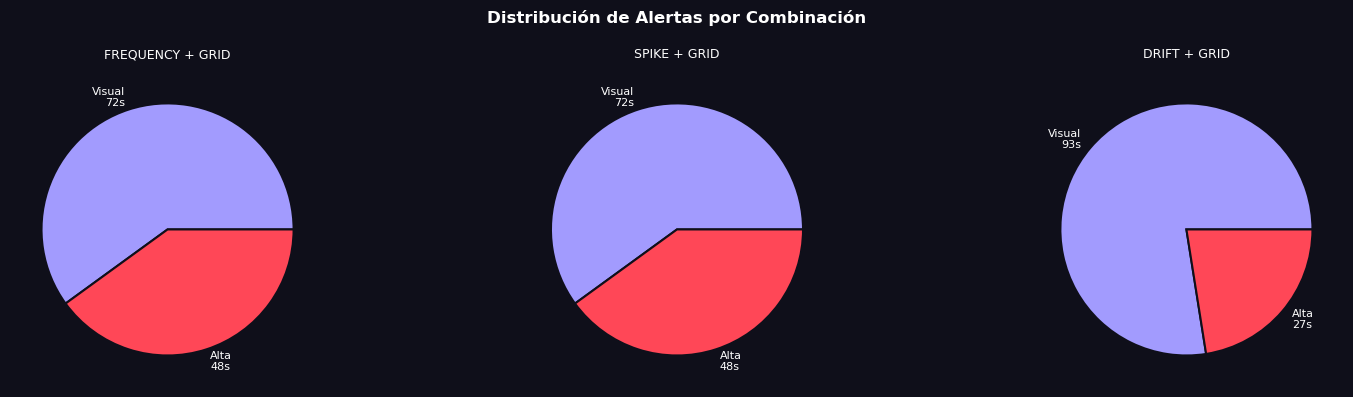


✔ Resumen guardado en data/dashboard/resumen_final.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

if timelines:
    fig, axes = plt.subplots(1, len(timelines), figsize=(16, 4),
                              facecolor='#0f0f1a')
    if len(timelines) == 1:
        axes = [axes]

    alert_colors = {
        0: '#00d4ff', 1: '#ffa502', 2: '#a29bfe', 3: '#ff4757'
    }
    alert_labels = {
        0: 'Normal', 1: 'Vib', 2: 'Visual', 3: 'Alta'
    }

    for ax, (name, tl) in zip(axes, timelines.items()):
        ax.set_facecolor('#1a1a2e')
        dist   = tl['alert_level'].value_counts().sort_index()
        colors = [alert_colors[i] for i in dist.index]
        labels = [f"{alert_labels[i]}\n{v}s" for i, v in dist.items()]
        ax.pie(dist.values, labels=labels, colors=colors,
               textprops={'color': 'white', 'fontsize': 8},
               wedgeprops={'edgecolor': '#0f0f1a', 'linewidth': 1.5})
        ax.set_title(name.replace('_', ' + ').upper(),
                     color='white', fontsize=9, pad=10)

    fig.suptitle('Distribución de Alertas por Combinación',
                 color='white', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DASH_DIR / 'resumen_final.png', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print('\n Resumen guardado en data/dashboard/resumen_final.png')

---
## Conclusiones

### Lo que aprendí elaborando el presente proyecto.

1. **FFT es muy efectiva** para detectar fallos de frecuencia y spike — aparece un pico claro en 80Hz que no existe en operación normal.

2. **El drift es el fallo más difícil** de detectar con métodos clásicos porque no introduce frecuencias nuevas, solo incrementa la energía gradualmente. Esto es consistente con la literatura de mantenimiento predictivo.

3. **Carpet vs Grid:** Las texturas orgánicas densas requieren análisis por parches locales en vez de métricas globales. El análisis global (Canny, Sobel) satura con la textura normal y no detecta defectos sutiles. Este es el problema conocido como *domain shift*.

4. **La correlación multimodal reduce falsos positivos:** Al requerir confirmación de dos fuentes independientes, el sistema es más confiable que cualquier sensor por sí solo.

### Límites del enfoque clásico

| Categoría | F1 obtenido | Límite clásico | Solución futura |
|---|---|---|---|
| Grid | 88.4% | ~90% | PatchCore |
| Carpet | 53.1% | ~65% | AutoEncoder Convolucional |

### Escalabilidad futura

- Conectar **sensores reales** de vibración (MEMS industriales)
- Integrar **cámara industrial** en tiempo real
- Entrenar **PatchCore** con las máscaras `ground_truth/` de MVTec
- Construir **API REST** para integración con sistemas SCADA

---